# Business Problem Statement

The gaming industry relies heavily on player engagement and in-game purchases to sustain revenue. Understanding player behavior is essential for improving retention, optimizing gameplay experiences, and identifying high-value users.

Gaming companies often face three key challenges:

Identifying players who are likely to disengage or churn

Understanding the factors that drive player engagement

Identifying player segments that generate the most revenue

Addressing these challenges enables gaming companies to design targeted engagement strategies, improve player retention, and maximize revenue.

This project analyzes player behavior data to answer the following business questions:

Which players are most likely to churn?

What factors drive player engagement?

Which player segments generate the most revenue?

Insights from this analysis can help gaming companies develop strategies to improve player retention, personalize gameplay experiences, and optimize monetization strategies.

# Project Objectives

The main objectives of this analysis are:

Analyze player demographics and gameplay behavior.

Identify patterns associated with high and low engagement levels.

Detect potential churn-risk players.

Identify high-value player segments based on spending behavior.

Provide data-driven recommendations for improving player engagement and revenue.

# Dataset Description

The dataset contains behavioral and demographic information about 40,034 players.

Each row represents a unique player and includes gameplay metrics, demographics, and engagement indicators.

Dataset Overview
Column	Description
PlayerID:	Unique identifier for each player
Age:	Player age
Gender:	Player gender
Location:	Player geographical location
GameGenre:	Type of game played
PlayTimeHours:	Total hours spent playing
InGamePurchases:	Number of in-game purchases made
GameDifficulty:	Difficulty level of the game
SessionsPerWeek:	Number of game sessions per week
AvgSessionDurationMinutes:	Average session duration
PlayerLevel:	Current level achieved by player
AchievementsUnlocked:	Number of achievements unlocked
EngagementLevel	Player: engagement classification (Low, Medium, High)

The EngagementLevel variable will be used as a proxy indicator for player engagement and churn risk.

Players with Low engagement may be considered at risk of churn.

# Data Loaded

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving online_gaming_behavior_dataset.xlsx to online_gaming_behavior_dataset.xlsx


In [5]:
gaming_data = pd.read_excel('online_gaming_behavior_dataset.xlsx')

In [6]:
gaming_data.head()
gaming_data.info()
gaming_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [7]:
gaming_data.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


# Checking Missing Values

In [8]:
gaming_data.isnull().sum()

,0
PlayerID,0
Age,0
Gender,0
Location,0
GameGenre,0
PlayTimeHours,0
InGamePurchases,0
GameDifficulty,0
SessionsPerWeek,0
AvgSessionDurationMinutes,0


# In this dataset, no missing values were found, which simplifies the preprocessing stage.

# Exploratory Data Analysis (EDA)

# Player Engagement Distribution

In [9]:
gaming_data['EngagementLevel'].value_counts()

,count
EngagementLevel,
Medium,19374
High,10336
Low,10324


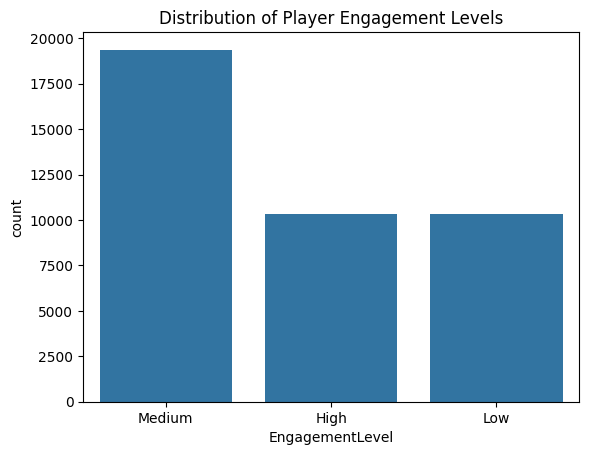

In [10]:
sns.countplot(data=gaming_data, x='EngagementLevel')
plt.title("Distribution of Player Engagement Levels")
plt.show()

# Interpretation

The majority of players fall into the Medium engagement category, accounting for 19,374 players, which is approximately 48% of the total player base.

Both High engagement and Low engagement players represent similar proportions of the dataset, with 10,336 and 10,324 players respectively.

This distribution suggests that:

Nearly half of the player base maintains moderate engagement levels.

A significant portion of players (over 25%) are highly engaged, indicating a loyal user segment.

Another 25% of players show low engagement, which may represent players at risk of churn.

# Business Insight

Players categorized under Low engagement represent a potential churn-risk group. Gaming companies could implement strategies such as:

Targeted promotions

Gameplay incentives

Personalized notifications

to re-engage these players and prevent them from leaving the platform.

Meanwhile, High engagement players represent a valuable segment that companies may prioritize through:

Loyalty rewards

Exclusive content

Premium features

to maintain long-term engagement and maximize revenue.

# Playtime vs Engagement

In [11]:
Total_playing_time = gaming_data.groupby('EngagementLevel').agg(
    total_players=('PlayerID','count'),
    total_play_time=('PlayTimeHours','sum'),
    average_play_time=('PlayTimeHours','mean')
)

In [12]:
print(Total_playing_time)

                 total_players  total_play_time  average_play_time
EngagementLevel                                                   
High                     10336    124747.644724          12.069238
Low                      10324    124971.138441          12.104915
Medium                   19374    231664.660191          11.957503


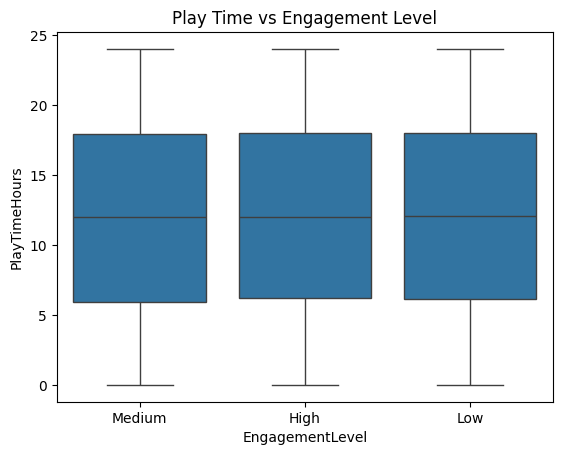

In [13]:
sns.boxplot(x='EngagementLevel', y='PlayTimeHours', data=gaming_data)
plt.title("Play Time vs Engagement Level")
plt.show()

# Interpretation

The boxplot illustrates the relationship between total playtime and player engagement levels.

Key observations include:

The median playtime across all engagement levels appears relatively similar.

The distribution of playtime is fairly consistent among Low, Medium, and High engagement groups.

There is no strong separation in playtime between engagement categories.

This suggests that total playtime alone may not be the primary factor driving player engagement.

# Business Insight

Although playtime is an important behavioral metric, this analysis suggests that other factors such as session frequency, achievements, or player progression may play a stronger role in determining engagement levels.

Gaming companies should therefore consider additional engagement indicators beyond total hours played when identifying highly engaged players.

# Sessions Per Week vs Engagement Level

In [14]:
Total_sessions = gaming_data.groupby('EngagementLevel').agg(
    total_players=('PlayerID','count'),
    total_sessions_per_week=('SessionsPerWeek','sum'),
    average_sessions_per_week=('SessionsPerWeek','mean')
)

In [15]:
print(Total_sessions)

                 total_players  total_sessions_per_week  \
EngagementLevel                                           
High                     10336                   147335   
Low                      10324                    46773   
Medium                   19374                   185085   

                 average_sessions_per_week  
EngagementLevel                             
High                             14.254547  
Low                               4.530511  
Medium                            9.553267  


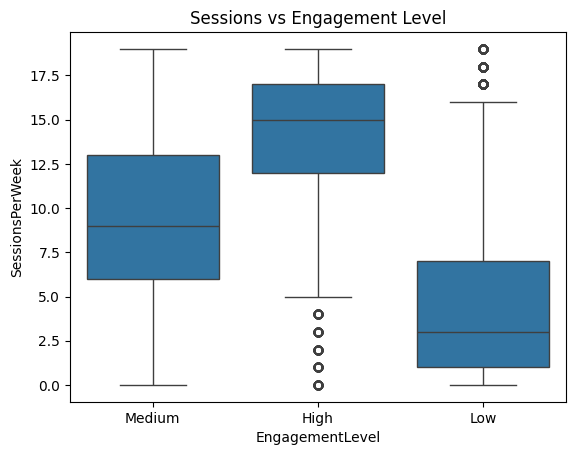

In [16]:
sns.boxplot(x='EngagementLevel', y='SessionsPerWeek', data=gaming_data)
plt.title("Sessions vs Engagement Level")
plt.show()

# Interpretation

The visualization reveals a clear relationship between session frequency and engagement level.

Key observations include:

Highly engaged players tend to have the highest number of sessions per week, with a median around 14–15 sessions.

Medium engagement players show a moderate level of activity, with a median around 8–9 sessions per week.

Low engagement players have the lowest session frequency, typically around 2–4 sessions per week.

This indicates that session frequency is strongly associated with player engagement.

# Business Insight

The number of sessions per week appears to be a key driver of player engagement.

Players who log in frequently are significantly more likely to fall into the high engagement category, while players with fewer sessions are more likely to exhibit low engagement and potential churn risk.

Gaming companies could use this insight to:

Identify players whose session frequency is declining

Trigger re-engagement strategies such as notifications or rewards

Encourage consistent gameplay through daily login incentives or challenges

# PlayerLevel vs Engagement Level

In [17]:
Total_player_level = gaming_data.groupby('EngagementLevel').agg(
    total_players=('PlayerID','count'),
    total_player_level=('PlayerLevel','sum'),
    average_player_level=('PlayerLevel','mean')
)

In [18]:
print(Total_player_level)

                 total_players  total_player_level  average_player_level
EngagementLevel                                                         
High                     10336              525314             50.823723
Low                      10324              475951             46.101414
Medium                   19374              986646             50.926293


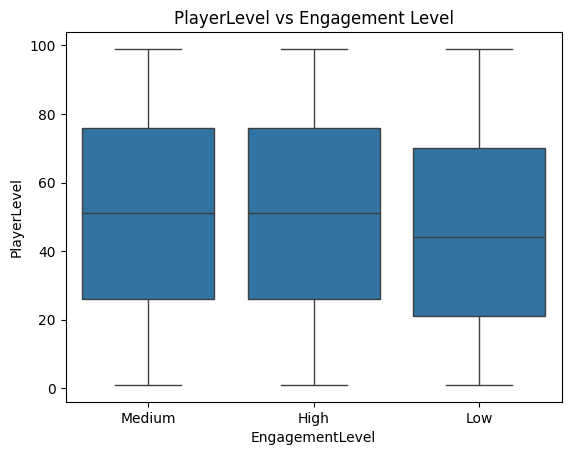

In [19]:
sns.boxplot(x='EngagementLevel', y='PlayerLevel', data=gaming_data)
plt.title("PlayerLevel vs Engagement Level")
plt.show()

# Interpretation

The boxplot compares player progression levels across Low, Medium, and High engagement groups.

Key observations include:

High engagement players generally show slightly higher player levels compared to low engagement players.

Medium engagement players appear to have a similar median level to high engagement players.

Low engagement players tend to have slightly lower median progression levels.

However, there is significant overlap in player levels across all engagement groups.

This suggests that while player progression may contribute to engagement, player level alone does not strongly differentiate engagement categories.

# Business Insight

Player progression contributes to engagement, but it is not the strongest driver compared to behavioral metrics like session frequency.

This implies that:

Players may reach higher levels but still disengage later.

Continuous engagement strategies may be required even for experienced players.

Gaming companies may improve engagement by:

Introducing new challenges or achievements for high-level players

Providing progression-based rewards

Maintaining gameplay variety to keep experienced players active.

# AchievementsUnlocked vs EngagementLevel

In [20]:
Total_achievement = gaming_data.groupby('EngagementLevel').agg(
    total_players=('PlayerID','count'),
    total_achievement_unlocked=('AchievementsUnlocked','sum'),
    average_achievement_unlocked=('AchievementsUnlocked','mean')
)

In [21]:
print(Total_achievement)

                 total_players  total_achievement_unlocked  \
EngagementLevel                                              
High                     10336                      259392   
Low                      10324                      233958   
Medium                   19374                      488543   

                 average_achievement_unlocked  
EngagementLevel                                
High                                25.095975  
Low                                 22.661565  
Medium                              25.216424  


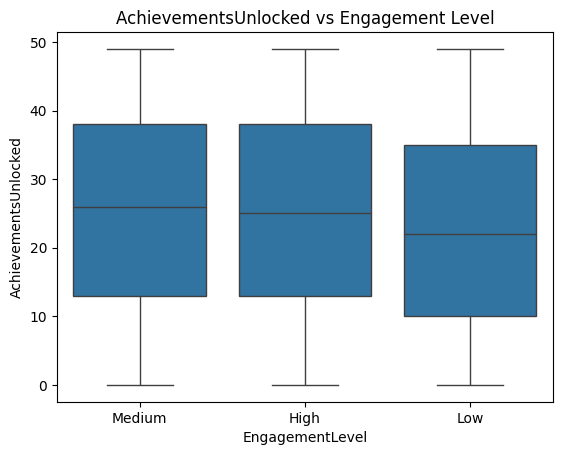

In [22]:
sns.boxplot(x='EngagementLevel', y='AchievementsUnlocked', data=gaming_data)
plt.title("AchievementsUnlocked vs Engagement Level")
plt.show()

# Interpretation

The visualization compares the number of achievements unlocked by players across different engagement categories.

Key observations include:

Highly engaged players generally unlock a greater number of achievements.

Medium engagement players also show relatively high achievement counts.

Low engagement players tend to unlock fewer achievements overall.

Although there is some overlap between the categories, players with higher engagement levels appear to consistently achieve more in-game milestones.

# Business Insight

Achievements appear to play a role in maintaining player engagement.

Players who unlock more achievements are likely to remain actively involved in the game, suggesting that achievement systems can encourage continued gameplay.

Gaming companies can leverage this insight by:

Designing achievement-based progression systems

Introducing reward-based challenges

Offering exclusive rewards for milestone achievements

These strategies can help increase player motivation and long-term engagement.

# AvgSessionDurationMinutes vs Engagement Level

In [23]:
Total_duration_session = gaming_data.groupby('EngagementLevel').agg(
    total_players=('PlayerID','count'),
    total_duration_session=('AvgSessionDurationMinutes','sum'),
    average_duration_session=('AvgSessionDurationMinutes','mean')
)

In [24]:
print(Total_duration_session)

                 total_players  total_duration_session  \
EngagementLevel                                          
High                     10336                 1363544   
Low                      10324                  690491   
Medium                   19374                 1740878   

                 average_duration_session  
EngagementLevel                            
High                           131.921827  
Low                             66.882119  
Medium                          89.856405  


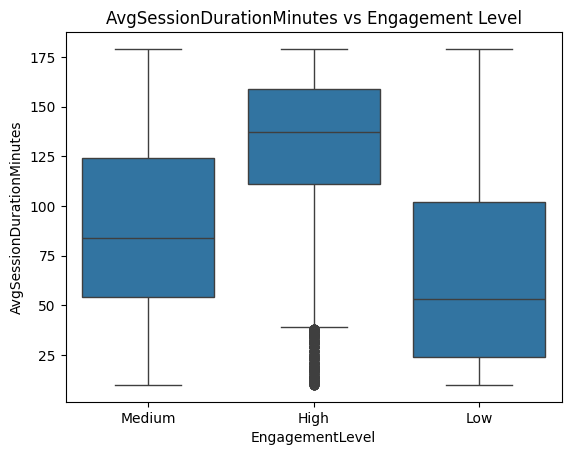

In [25]:
sns.boxplot(x='EngagementLevel', y='AvgSessionDurationMinutes', data=gaming_data)
plt.title("AvgSessionDurationMinutes vs Engagement Level")
plt.show()

# Interpretation

The analysis shows clear differences in session duration across engagement levels.

Key findings:

Highly engaged players spend the longest time per session, with an average session duration of ~132 minutes.

Medium engagement players spend an average of ~90 minutes per session.

Low engagement players have the shortest sessions, averaging ~67 minutes.

This indicates a strong relationship between session duration and engagement level.

# Business Insight

Players who spend more time per gaming session are significantly more likely to fall into the high engagement category.

This suggests that longer gameplay sessions contribute to stronger player engagement and retention.

Gaming companies can leverage this insight by:

Designing gameplay features that encourage longer play sessions

Introducing extended missions or challenges

Implementing progressive rewards for longer gameplay sessions

Encouraging players to stay in the game longer may increase engagement and reduce churn risk.

# Key Findings from Exploratory Data Analysis

The exploratory analysis identified several behavioral patterns influencing player engagement:

Session frequency is the strongest indicator of engagement, with highly engaged players participating in significantly more sessions per week.

Achievement completion contributes to engagement, as highly engaged players tend to unlock more achievements.

Player progression (level) shows some relationship with engagement but does not strongly differentiate engagement groups.

Total playtime alone is not a strong predictor of engagement, suggesting that how frequently players interact with the game is more important than total time spent.

These findings highlight the importance of encouraging frequent gameplay interactions to sustain player engagement.

In [26]:
gaming_data.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


# Which player segments generate the most revenue?

In [27]:
revenue_analysis = gaming_data.groupby('EngagementLevel').agg(
    total_players=('PlayerID','count'),
    total_purchases=('InGamePurchases','sum'),
    avg_purchases=('InGamePurchases','mean')
)

In [28]:
print(revenue_analysis)

                 total_players  total_purchases  avg_purchases
EngagementLevel                                               
High                     10336             2134       0.206463
Low                      10324             2037       0.197307
Medium                   19374             3870       0.199752


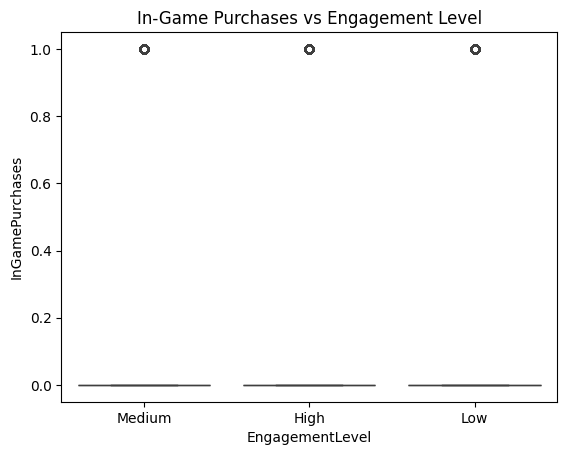

In [29]:
sns.boxplot(x='EngagementLevel', y='InGamePurchases', data=gaming_data)
plt.title("In-Game Purchases vs Engagement Level")
plt.show()

# Interpretation

The analysis examines how in-game purchases vary across different engagement levels.

Key observations:

Medium engagement players generated the highest total purchases (3,870) because they represent the largest player segment.

Highly engaged players have the highest average purchases per player (~0.206).

Low engagement players have the lowest purchasing activity (~0.197).

Although the differences in average purchases per player are relatively small, the trend suggests that more engaged players tend to spend slightly more on in-game purchases.

# Business Insight

This analysis indicates that player engagement is positively associated with in-game spending.

Important takeaways:

Highly engaged players are the most valuable on a per-player basis.

Medium engagement players generate the highest total revenue due to their larger population.

Low engagement players contribute the least to monetization.

Gaming companies could use these insights to:

Focus monetization strategies on highly engaged players

Encourage medium engagement players to transition into high engagement

Develop targeted incentives to increase spending among active users

# Which players are most likely to churn?

# Business Context

Player churn is a critical issue in gaming because losing active players directly affects long-term revenue and community growth. Identifying players at risk of churn allows gaming companies to implement retention strategies before players disengage completely.

# Step 1: Define Churn Proxy
Since we do not have a direct churn variable, we can use Low Engagement players as churn-risk players

In [30]:
gaming_data['ChurnRisk'] = gaming_data['EngagementLevel'].apply(lambda x: 1 if x == 'Low' else 0)

# Churn Distribution

In [31]:
gaming_data['ChurnRisk'].value_counts()

,count
ChurnRisk,
0,29710
1,10324


# Interpretation

The dataset shows that 10,324 players are classified as being at risk of churn, representing approximately 26% of the total player base.

This indicates that about one quarter of players demonstrate low engagement behaviors, making them more likely to discontinue playing the game.

Meanwhile, 74% of players remain active, showing moderate to high engagement with the game.

# Business Insight

A churn-risk segment of 26% is significant for a gaming platform because losing these players could lead to:

Reduced player activity

Lower in-game purchase revenue

Decline in community engagement

To mitigate churn risk, gaming companies can implement player retention strategies, such as:

Personalized rewards for inactive players

Daily login bonuses

Targeted in-game challenges

Notifications encouraging players to return to the game

These strategies aim to re-engage players before they completely disengage from the platform.

# Identify Characteristics of Churn-Risk Players

# Sessions per Week vs Churn Risk

In [32]:
churnrisk_analysis = gaming_data.groupby('EngagementLevel').agg(
    total_players=('PlayerID','count'),
    total_churn_players=('ChurnRisk','sum'),
    avg_churn_players=('ChurnRisk','mean')
)

In [33]:
print(churnrisk_analysis)

                 total_players  total_churn_players  avg_churn_players
EngagementLevel                                                       
High                     10336                    0                0.0
Low                      10324                10324                1.0
Medium                   19374                    0                0.0


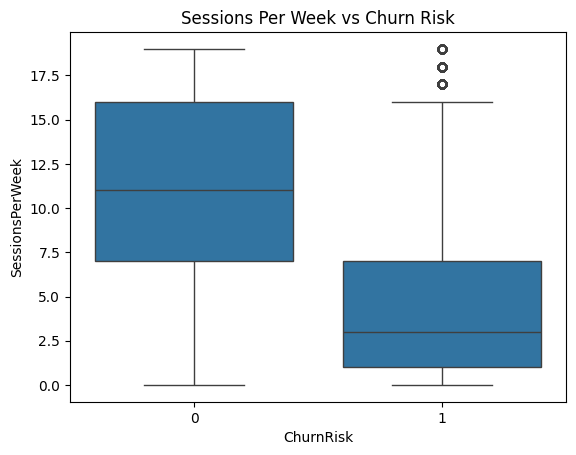

In [34]:
sns.boxplot(x='ChurnRisk', y='SessionsPerWeek', data=gaming_data)
plt.title("Sessions Per Week vs Churn Risk")
plt.show()

# Session Duration vs Churn Risk

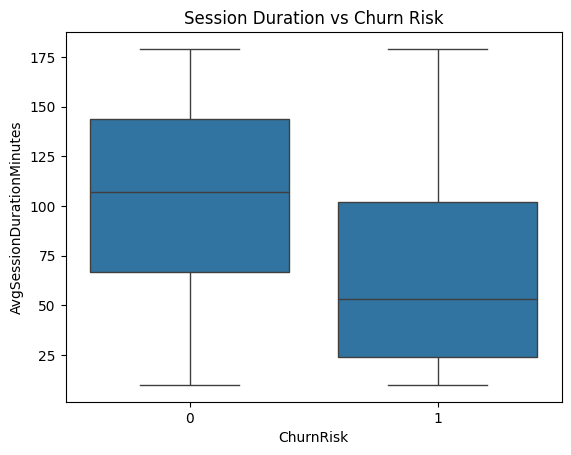

In [35]:
sns.boxplot(x='ChurnRisk', y='AvgSessionDurationMinutes', data=gaming_data)
plt.title("Session Duration vs Churn Risk")
plt.show()

# Achievements vs Churn Risk

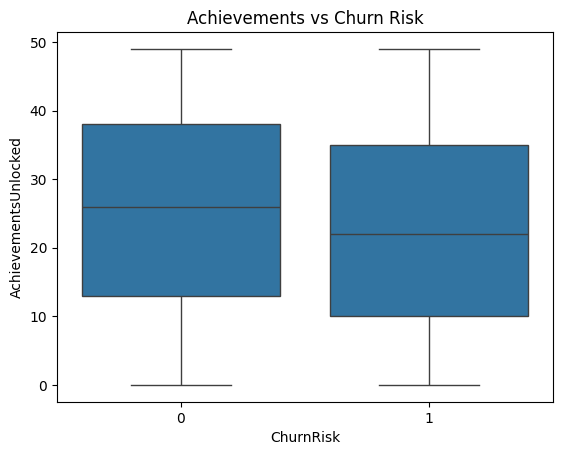

In [36]:
sns.boxplot(x='ChurnRisk', y='AchievementsUnlocked', data=gaming_data)
plt.title("Achievements vs Churn Risk")
plt.show()

# What Behaviors Predict Player Churn?

In [37]:
churn_behavior = gaming_data.groupby('ChurnRisk')[[
    'SessionsPerWeek',
    'AvgSessionDurationMinutes',
    'AchievementsUnlocked',
    'PlayTimeHours',
    'InGamePurchases'
]].mean()

churn_behavior

,SessionsPerWeek,AvgSessionDurationMinutes,AchievementsUnlocked,PlayTimeHours,InGamePurchases
ChurnRisk,,,,,
0,11.188825,104.490811,25.174520,11.996375,0.202087
1,4.530511,66.882119,22.661565,12.104915,0.197307


# Key Insights
1️⃣ Session Frequency is the Strongest Indicator of Churn

Active players participate in about 11 sessions per week, while churn-risk players average only about 4–5 sessions.

This large difference suggests that reduced login frequency is a major signal of disengagement.

2️⃣ Churn-Risk Players Have Shorter Gaming Sessions

Active players spend an average of ~104 minutes per session, while churn-risk players average ~67 minutes.

This indicates that less committed players spend significantly less time playing.

3️⃣ Achievement Progress is Slightly Lower for Churn-Risk Players

Active players unlock slightly more achievements (25 vs 22), suggesting that progression systems help maintain engagement.

4️⃣ Total Playtime Does Not Clearly Differentiate Churn

Interestingly, PlayTimeHours is very similar for both groups, indicating that total playtime alone does not predict churn risk.

5️⃣ Spending Behavior is Almost Identical

Average in-game purchases are very similar (~0.20) for both groups, suggesting that spending alone is not a strong predictor of churn.

# Business Insight

The analysis indicates that player engagement behaviors — particularly session frequency and session duration — are the strongest indicators of churn risk.

Players who:

Log in less frequently

Spend less time per gaming session

are significantly more likely to disengage from the game.

Gaming companies can reduce churn by identifying players whose session frequency or session duration declines, and intervening with retention strategies such as:

Login rewards

Personalized notifications

Limited-time events

Achievement-based challenges

# Player Segmentation Using Clustering

# Business Objective

The goal of player segmentation is to group players based on behavioral patterns such as play frequency, session duration, and achievements. These segments help gaming companies design targeted engagement and monetization strategies.

# Step 1: Select Features for Segmentation

In [39]:
features = gaming_data[['SessionsPerWeek',
               'AvgSessionDurationMinutes',
               'AchievementsUnlocked',
               'PlayTimeHours']]

# Step 2: Feature Scaling

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 3: Determine Optimal Number of Clusters (Elbow Method)

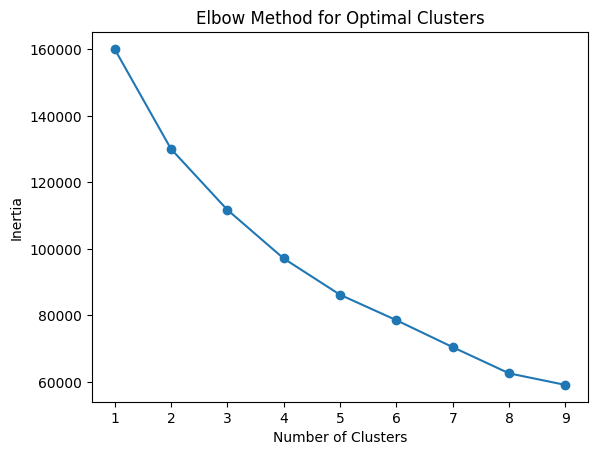

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Step 4: Apply K-Means Clustering

In [42]:
kmeans = KMeans(n_clusters=3, random_state=42)
gaming_data['PlayerSegment'] = kmeans.fit_predict(scaled_features)

# Step 5: Analyze the Segments

In [44]:
segment_analysis = gaming_data.groupby('PlayerSegment')[[
    'SessionsPerWeek',
    'AvgSessionDurationMinutes',
    'AchievementsUnlocked',
    'PlayTimeHours'
]].mean()

segment_analysis

,SessionsPerWeek,AvgSessionDurationMinutes,AchievementsUnlocked,PlayTimeHours
PlayerSegment,,,,
0,9.467881,140.215884,15.332614,12.127370
1,9.514531,95.217038,39.720104,12.076277
2,9.424417,48.859460,15.508869,11.859138


# Step 6: Visualize Player Segments

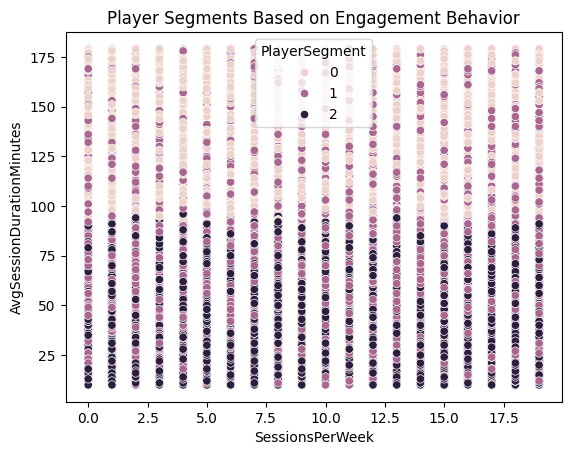

In [45]:
import seaborn as sns

sns.scatterplot(
    data= gaming_data,
    x='SessionsPerWeek',
    y='AvgSessionDurationMinutes',
    hue='PlayerSegment'
)

plt.title("Player Segments Based on Engagement Behavior")
plt.show()

# Segment Interpretation
# Segment 0 — Long Session Players

Characteristics:

Longest session duration (~140 minutes)

Moderate achievements

Moderate weekly sessions

These players stay in the game for long periods once they start playing.

Business Meaning

These players are likely immersive gamers who enjoy extended gameplay sessions such as story modes or competitive matches.

Strategy

Offer long-session rewards

Introduce extended missions or campaigns

Promote competitive gameplay modes

# Segment 1 — Achievement-Oriented Players

Characteristics:

Highest achievement unlocks (~40)

Moderate session duration

Consistent weekly sessions

These players are progression-driven gamers.

Business Meaning

They are motivated by progress, levels, and achievements.

Strategy

Add achievement systems

Provide milestone rewards

Introduce leaderboards or ranking systems

These players are often loyal and highly engaged users.

# Segment 2 — Casual Players

Characteristics:

Shortest session duration (~49 minutes)

Lower achievements

Similar session frequency

These players log in regularly but play for shorter periods.

Business Meaning

They are likely casual gamers with lower engagement intensity.

Strategy

Introduce quick-play modes

Provide daily rewards

Send engagement notifications

These players represent a segment that could be converted into more engaged users.

# Key Insight

Interestingly, SessionsPerWeek is very similar across segments, meaning:

Session length and achievement progression differentiate players more than login frequency.

This is a very strong insight.

# Business Impact

This segmentation helps gaming platforms:

Identify highly engaged progression players

Design features for immersive long-session players

Improve retention of casual players

Such insights enable targeted engagement and monetization strategies.

# Conclusion
Player segmentation analysis identified three distinct player groups: long-session players, achievement-oriented players, and casual players. While session frequency remained consistent across segments, session duration and achievement progression were the key differentiating factors. These insights highlight opportunities for targeted engagement strategies tailored to different player motivations.